In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [51]:
DATA_DIR = Path.cwd().parent.resolve() / "data"

dataset = "download"

img_in_dir = DATA_DIR / f"{dataset}/images"
mask_in_dir = DATA_DIR / f"{dataset}/masks"

img_out_dir = DATA_DIR / f"images/{dataset}"
label_out_dir = DATA_DIR / f"labels/{dataset}"

csv_out_dir = DATA_DIR / "metadata"
metadata_path = csv_out_dir / f"{dataset}_metadata.csv"

In [52]:
img_out_dir.mkdir(parents=True, exist_ok=True)
label_out_dir.mkdir(parents=True, exist_ok=True)
csv_out_dir.mkdir(parents=True, exist_ok=True)

In [53]:
def mask2label(mask):
    label = np.zeros_like(mask, dtype=np.uint8)
    label[(mask >= 0) & (mask <= 10)] = 0  # background
    label[(mask >= 20) & (mask <= 200)] = 1  # shadow
    label[(mask >= 250) & (mask <= 255)] = 2  # cloud
    return label

In [54]:
def convert_to_B02_B03_B04_B08_Mask(path: str | Path, mask_in_dir: str | Path, img_out_dir: str | Path, label_out_dir: str | Path, show: bool = False):
    metadata = []
    path = Path(path)
    if path.is_dir():
        # Process directory
        im_files = [f for ext in ("tif", "tiff", "png", "jpg") for f in path.rglob(f"*.{ext}")]
        for im_path in im_files:
            metadata.append(convert_to_B02_B03_B04_B08_Mask(im_path, mask_in_dir, img_out_dir, label_out_dir, show))
        return metadata
    else:
        # Process a single image
        filename = path.stem
        bgr = cv2.imread(str(path))
        height, width = bgr.shape[:2]

        chip_out_dir = Path(img_out_dir) / filename
        chip_out_dir.mkdir(parents=True, exist_ok=True)
        row = {
            "chip_id": filename,
            "location": "E0.0-N0.0",
            "datetime": "2020/02/02",
            "x_start": 0,
            "x_end": width,
            "y_start": 0,
            "y_end": height,
            "B02_path": f"{str(chip_out_dir)}/B02.tif",
            "B03_path": f"{str(chip_out_dir)}/B03.tif",
            "B04_path": f"{str(chip_out_dir)}/B04.tif",
            "B08_path": f"{str(chip_out_dir)}/B08.tif",
            "label_path": f"{str(label_out_dir)}/{filename}.tif",
        }

        # Interpolate all pixels at once
        # n_channels = 1
        # bgr_wavelengths = np.array([497, 560, 665])  # B, G, R wavelengths (nm)
        # target_wavelengths = np.linspace(835, 835, n_channels) # NIR wavelength range (nm)
        # f = interp1d(bgr_wavelengths.T, bgr, kind="linear", bounds_error=False, fill_value="extrapolate")
        # multispectral = f(target_wavelengths)
        # nir = np.clip(multispectral, 0, 255).astype(np.uint8)

        b = bgr[:, :, 0]
        g = bgr[:, :, 1]
        r = bgr[:, :, 2]
        nir = np.clip(0.0 * r + 0.2 * g + 0.8 * b, 0, 255).astype(np.uint8)

        cv2.imwrite(row["B02_path"], b)
        cv2.imwrite(row["B03_path"], g)
        cv2.imwrite(row["B04_path"], r)
        cv2.imwrite(row["B08_path"], nir)

        mask = cv2.imread(str(mask_in_dir / path.name), cv2.IMREAD_GRAYSCALE)
        if mask:
            mask = mask2label(mask)
            cv2.imwrite(row["label_path"], mask)

        if show:
            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.imshow(bgr)
            plt.title("Original RGB Image", fontsize=14)
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(nir, cmap='hot')
            plt.title("Generated NIR Image (835nm)", fontsize=14)
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        return row

In [55]:
metadata = convert_to_B02_B03_B04_B08_Mask(img_in_dir, mask_in_dir, img_out_dir, label_out_dir)
pd.DataFrame(metadata).to_csv(metadata_path, index=False)
metadata[0]

[ WARN:0@26416.667] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/data/download/masks/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788.jpg'): can't open/read file: check file path/integrity
[ WARN:0@26416.721] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/data/download/masks/GF1_PMS2_E75.6_N40.7_20260512_L1A14401389001.jpg'): can't open/read file: check file path/integrity
[ WARN:0@26416.773] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/data/download/masks/GF1_PMS2_E115.6_N30.7_20260513_L1A14402621001.jpg'): can't open/read file: check file path/integrity
[ WARN:0@26416.828] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/data/download/masks/GF1_PMS1_E115.7_N32.5_20260513_L1A14402735001.jpg'): can't open/read file: check file path/integrity
[ WARN:0@26416.882] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/

{'chip_id': 'GF6_PMS_E79.7_N35.0_20260513_L1A1420708788',
 'location': 'E0.0-N0.0',
 'datetime': '2020/02/02',
 'x_start': 0,
 'x_end': 1098,
 'y_start': 0,
 'y_end': 1011,
 'B02_path': '/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B02.tif',
 'B03_path': '/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B03.tif',
 'B04_path': '/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B04.tif',
 'B08_path': '/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B08.tif',
 'label_path': '/Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788.tif'}

In [4]:

from pathlib import Path

from loguru import logger
import pandas as pd
from PIL import Image
import torch

from MyCloudSenseNet.benchmark.cloud_dataset import CloudDataset
from MyCloudSenseNet.benchmark.cloud_model import CloudModel

BANDS = ["B02", "B03", "B04", "B08"]
MODEL_NAME = "unet"

def predict_chips(test_feature_path: Path, pred_out_dir: Path, fast_dev_run: bool = False):
        logger.info("Loading model weights")
        model_weights_path: Path = Path(f"benchmark/{MODEL_NAME}/assets/cloud_model.pt")

        logger.info("Loading model")
        model = CloudModel(bands=BANDS,
                           hparams={"weights": None},
                           model_name=MODEL_NAME)
        model.load_state_dict(torch.load(model_weights_path))

        logger.info("Loading metadata")
        x_paths = pd.read_csv(test_feature_path)
        if fast_dev_run:
            x_paths = x_paths.head(model.num_workers * model.num_workers)
        logger.info(f"Found {len(x_paths)} chips")

        dataset = CloudDataset(x_paths=x_paths, bands=BANDS)
        dataloader = torch.utils.data.DataLoader(dataset,
                                                 batch_size=1,
                                                 num_workers=0,
                                                 pin_memory=False)

        logger.info("Generating predictions in batches")
        for batch_index, batch in enumerate(dataloader):
            logger.debug(f"Predicting batch {batch_index} of {len(dataloader)}")
            device = next(model.parameters()).device
            x = batch["chip"].to(device)
            model.eval()
            with torch.no_grad():
                preds = model(x)
                preds = torch.argmax(preds, dim=1).cpu().numpy().astype("uint8")
            # preds = model.forward(x)
            # preds = torch.softmax(preds, dim=1)[:, 1]
            # preds = (preds > 0.5).detach().numpy().astype("uint8")
            # preds = torch.argmax(preds, dim=1).detach().numpy().astype("uint8")
            for chip_id, pred in zip(batch["chip_id"], preds):
                chip_pred_path = pred_out_dir / f"{chip_id}.tif"
                chip_pred_im = Image.fromarray(pred)
                chip_pred_im.save(chip_pred_path)

        logger.info(f"""Saved {len(list(pred_out_dir.glob("*.tif")))} predictions""")


/Users/hangzegao/PycharmProjects/cloud/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/hangzegao/PycharmProjects/cloud/.venv/lib/python3.14/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1077)>
  data = fetch_version_info()
/Users/hangzegao/PycharmProjects/cloud/.venv/lib/python3.14/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
from pathlib import Path
import random

data_dir = Path.cwd().parent.resolve() / "data"

dataset = "download"

img_in_dir = data_dir / f"images/{dataset}"
label_out_dir = data_dir / f"labels/{dataset}"
csv_out_dir = data_dir / "metadata"
pred_out_dir = data_dir / f"predictions/{dataset}"
pred_out_dir.mkdir(exist_ok=True, parents=True)

metadata_path = csv_out_dir / f"{dataset}_metadata.csv"

logger.info("Generating predictions in batches")
predict_chips(metadata_path, pred_out_dir)
logger.info(f"""Saved {len(list(pred_out_dir.glob("*.tif")))} predictions""")

2026-05-17 13:25:30.526 | INFO     | __main__:<module>:16 - Generating predictions in batches
2026-05-17 13:25:30.527 | INFO     | __main__:predict_chips:18 - Loading model weights
2026-05-17 13:25:30.527 | INFO     | __main__:predict_chips:21 - Loading model
2026-05-17 13:25:31.031 | INFO     | __main__:predict_chips:27 - Loading metadata
2026-05-17 13:25:31.033 | INFO     | __main__:predict_chips:31 - Found 12 chips
2026-05-17 13:25:31.033 | INFO     | __main__:predict_chips:39 - Generating predictions in batches
2026-05-17 13:25:31.070 | DEBUG    | __main__:predict_chips:41 - Predicting batch 0 of 12
2026-05-17 13:25:31.677 | DEBUG    | __main__:predict_chips:41 - Predicting batch 1 of 12
2026-05-17 13:25:31.941 | DEBUG    | __main__:predict_chips:41 - Predicting batch 2 of 12
2026-05-17 13:25:32.197 | DEBUG    | __main__:predict_chips:41 - Predicting batch 3 of 12
2026-05-17 13:25:32.465 | DEBUG    | __main__:predict_chips:41 - Predicting batch 4 of 12
2026-05-17 13:25:32.729 | DEB

/Users/hangzegao/PycharmProjects/cloud/data/images/download/adwp/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/adwp.tif


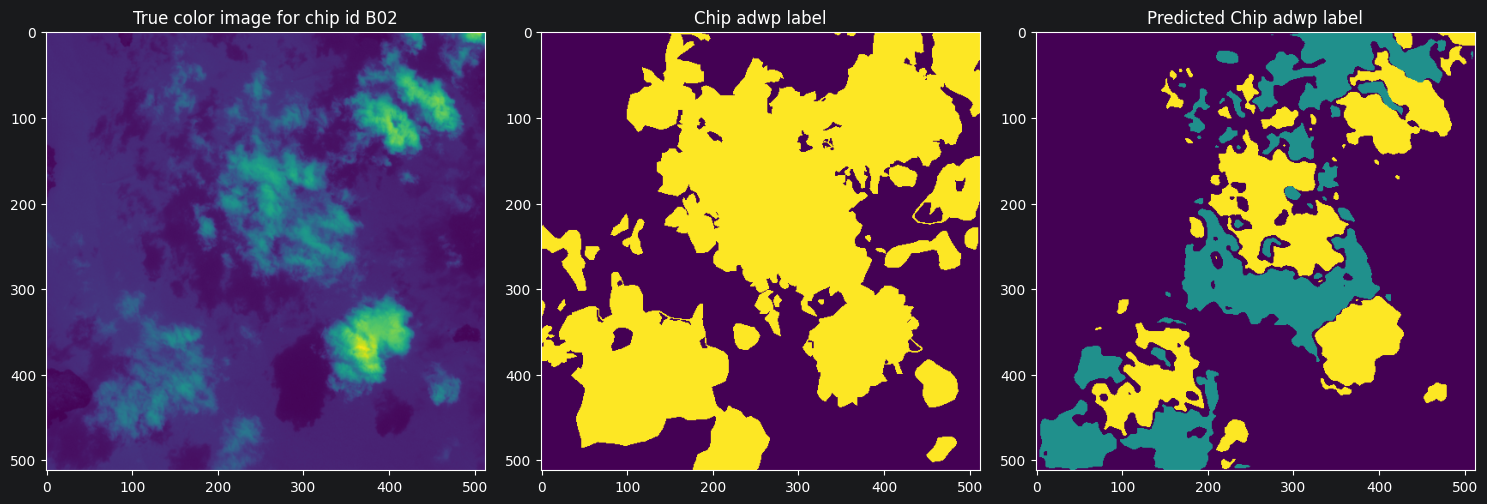

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS2_E75.6_N40.7_20260512_L1A14401389001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS2_E75.6_N40.7_20260512_L1A14401389001.tif


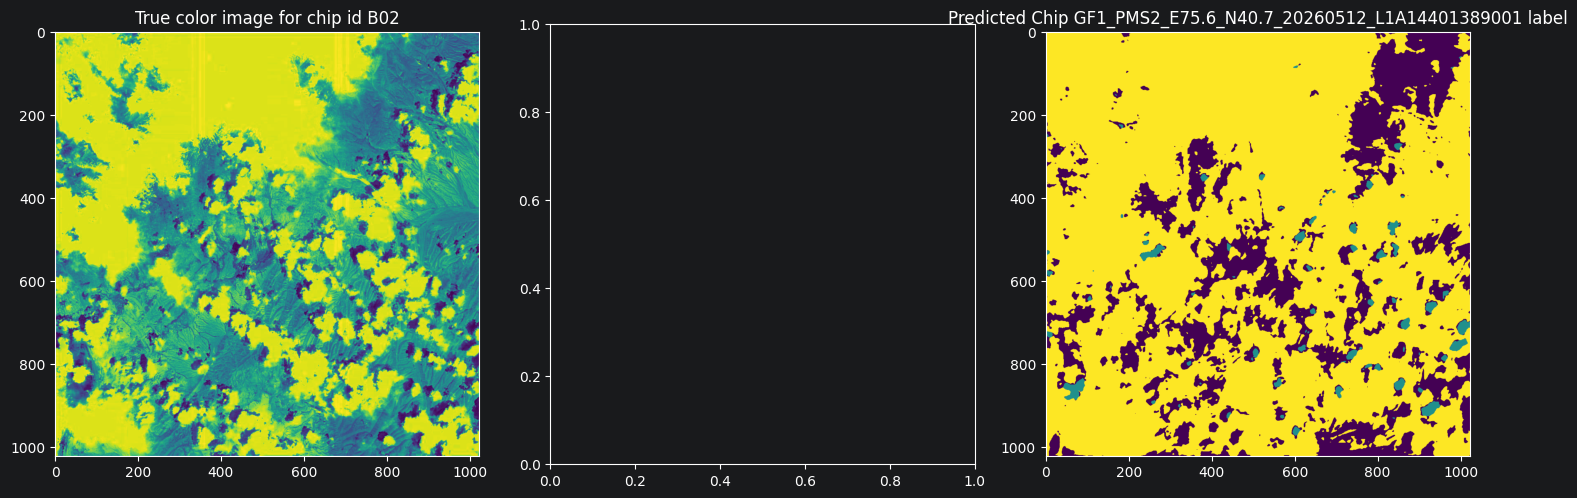

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS2_E91.4_N31.3_20260513_L1A14402851001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS2_E91.4_N31.3_20260513_L1A14402851001.tif


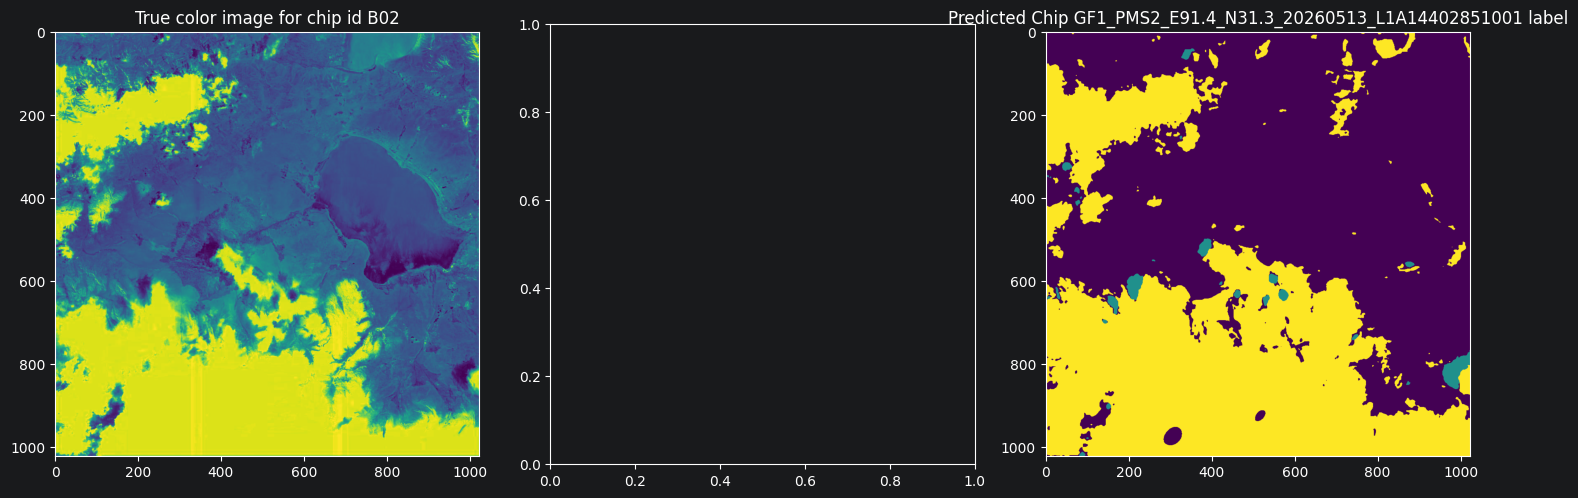

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS2_E90.7_N28.5_20260513_L1A14402861001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS2_E90.7_N28.5_20260513_L1A14402861001.tif


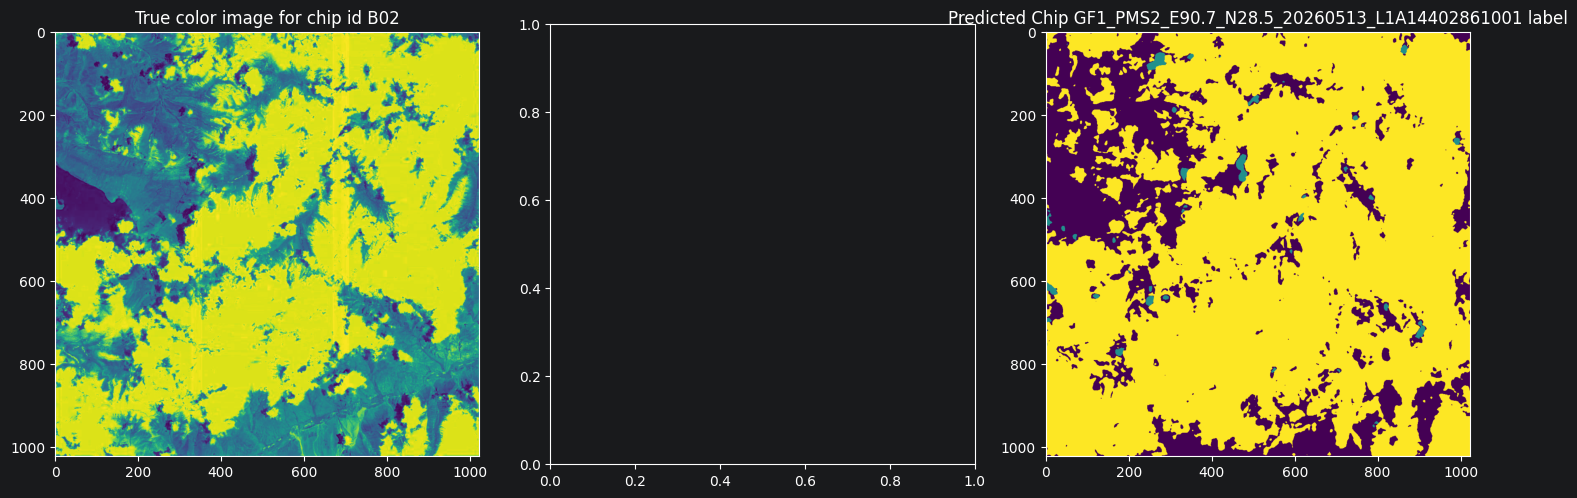

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS2_E116.1_N32.7_20260513_L1A14402614001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS2_E116.1_N32.7_20260513_L1A14402614001.tif


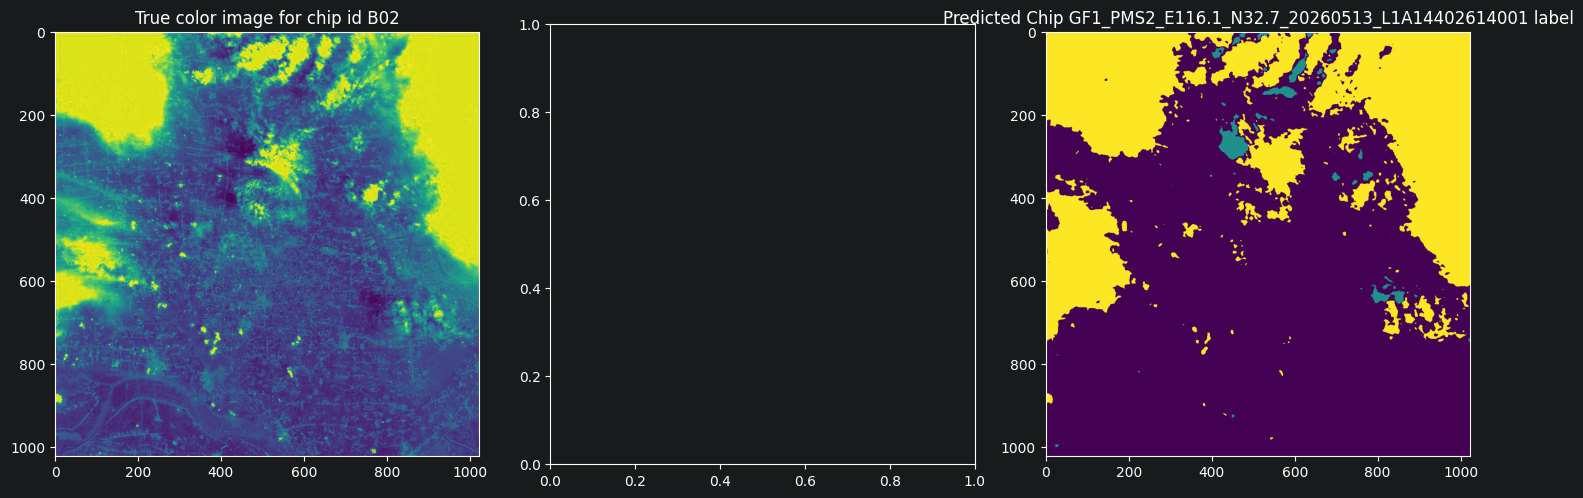

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS1_E113.2_N22.2_20260513_L1A14402772001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS1_E113.2_N22.2_20260513_L1A14402772001.tif


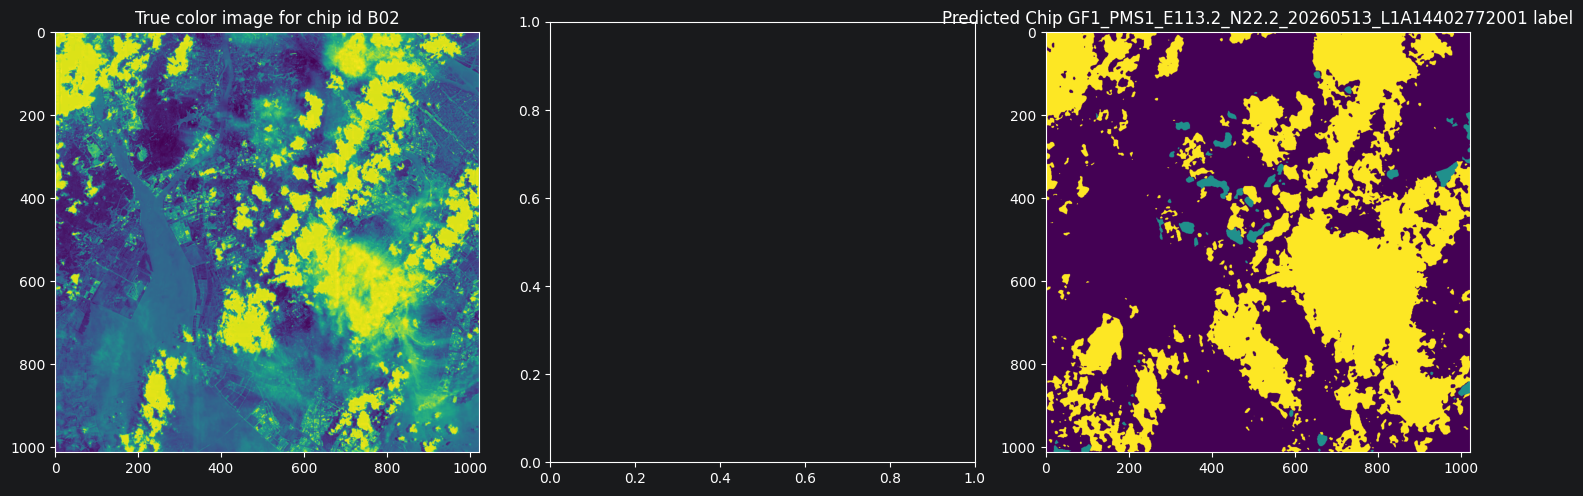

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS2_E113.7_N22.9_20260513_L1A14402649001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS2_E113.7_N22.9_20260513_L1A14402649001.tif


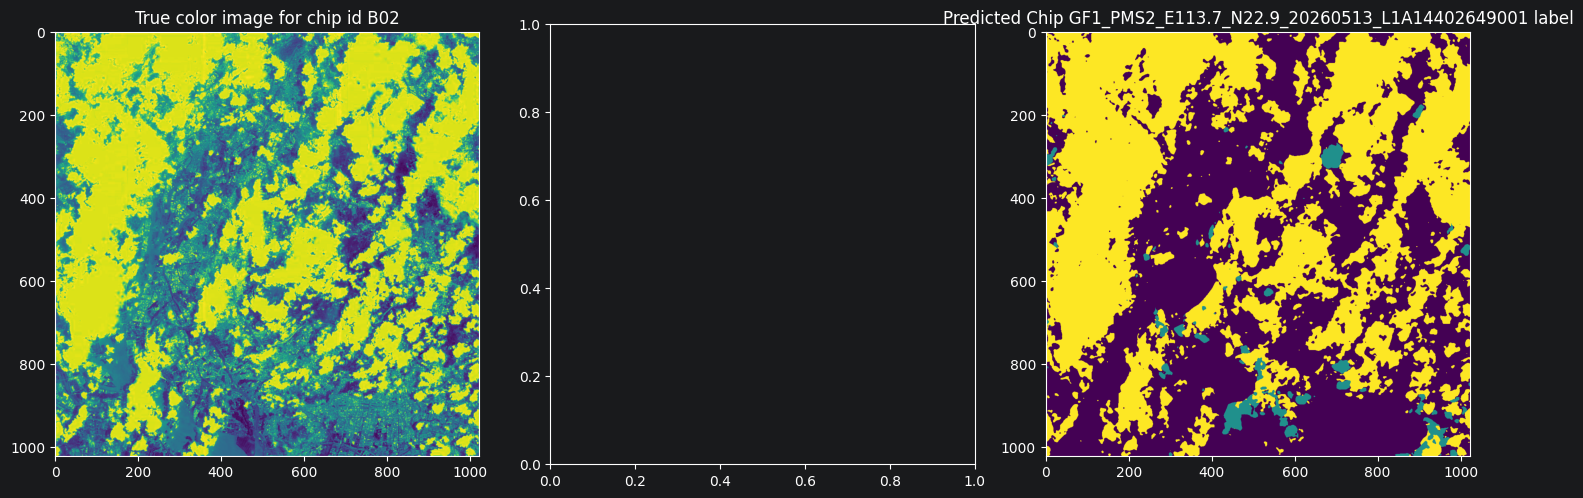

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS1_E115.7_N32.5_20260513_L1A14402735001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS1_E115.7_N32.5_20260513_L1A14402735001.tif


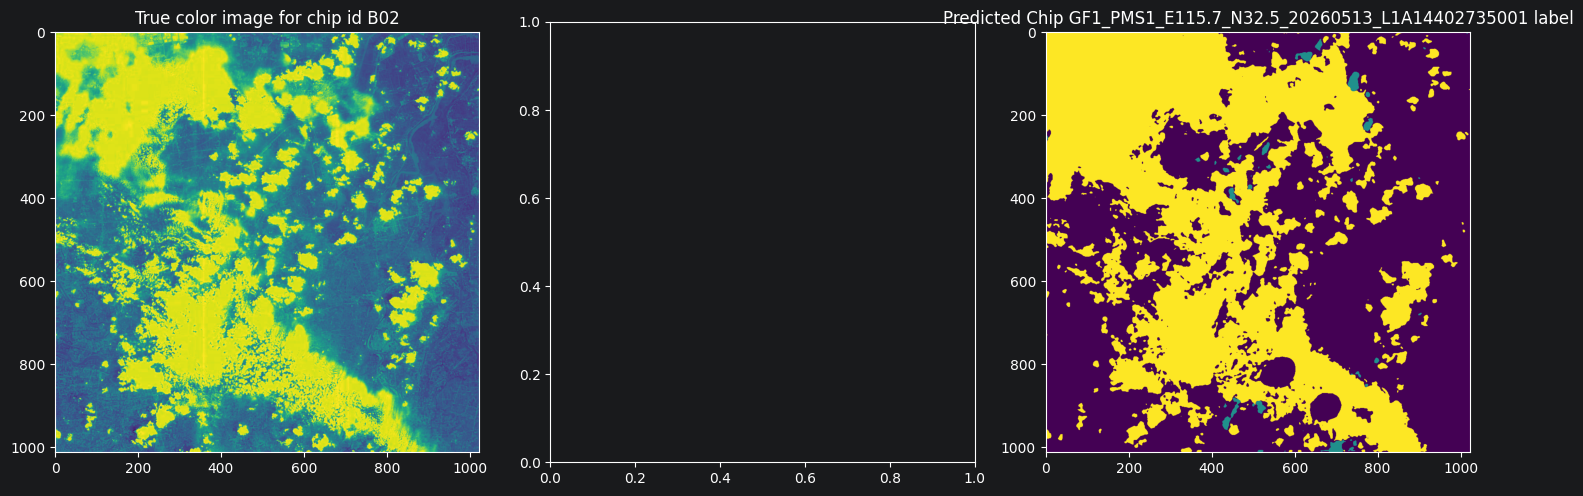

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788.tif


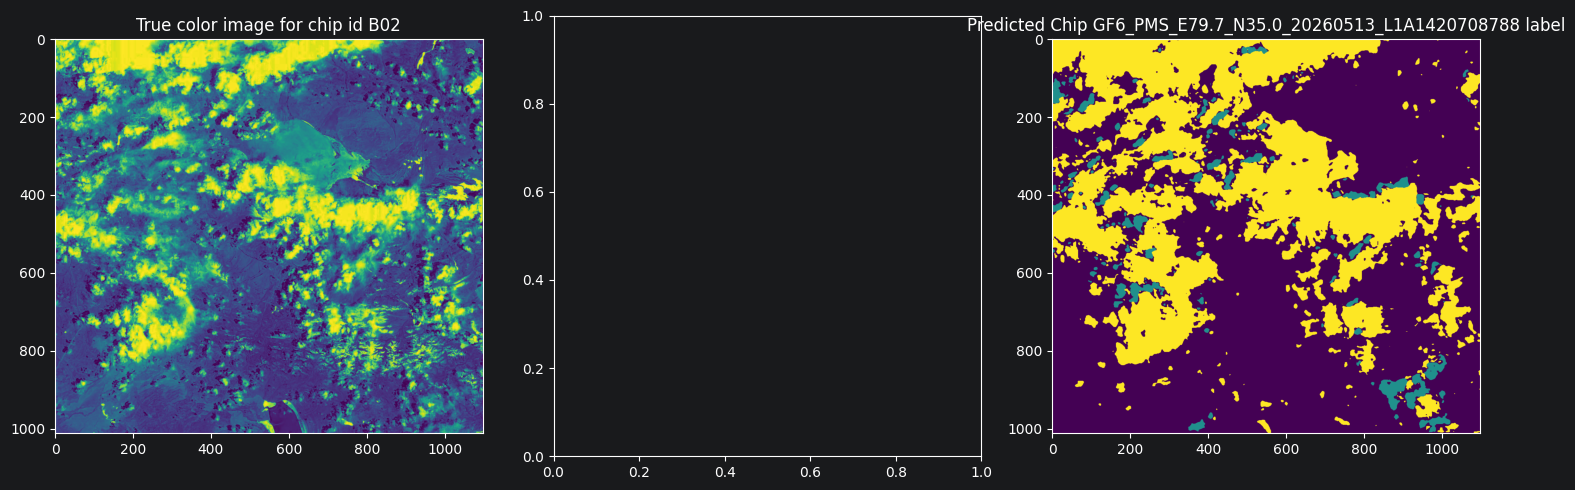

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS2_E115.6_N30.7_20260513_L1A14402621001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS2_E115.6_N30.7_20260513_L1A14402621001.tif


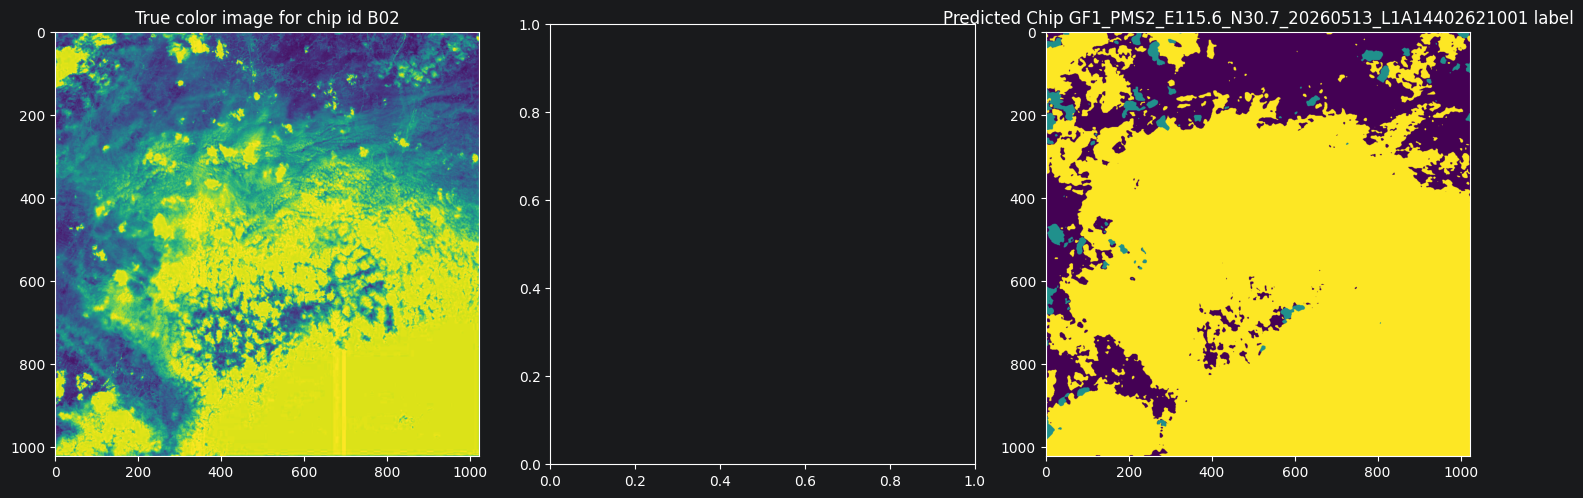

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS1_E116.1_N33.9_20260513_L1A14402730001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS1_E116.1_N33.9_20260513_L1A14402730001.tif


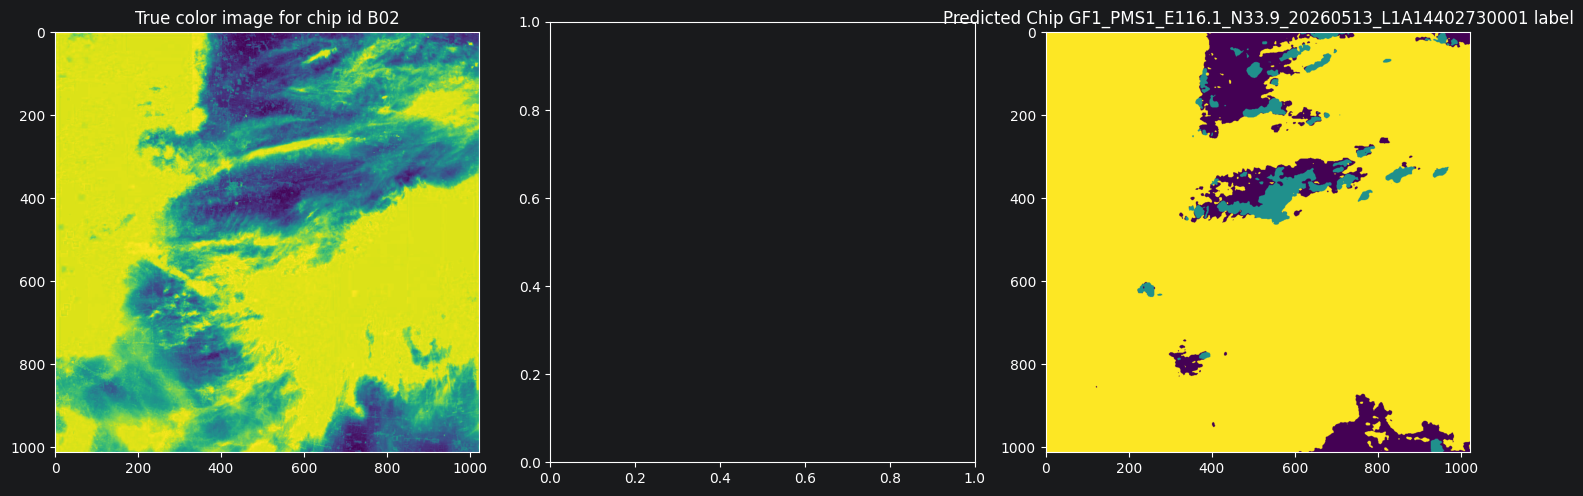

/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF1_PMS1_E120.0_N46.6_20260513_L1A14402684001/B02.tif /Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF1_PMS1_E120.0_N46.6_20260513_L1A14402684001.tif


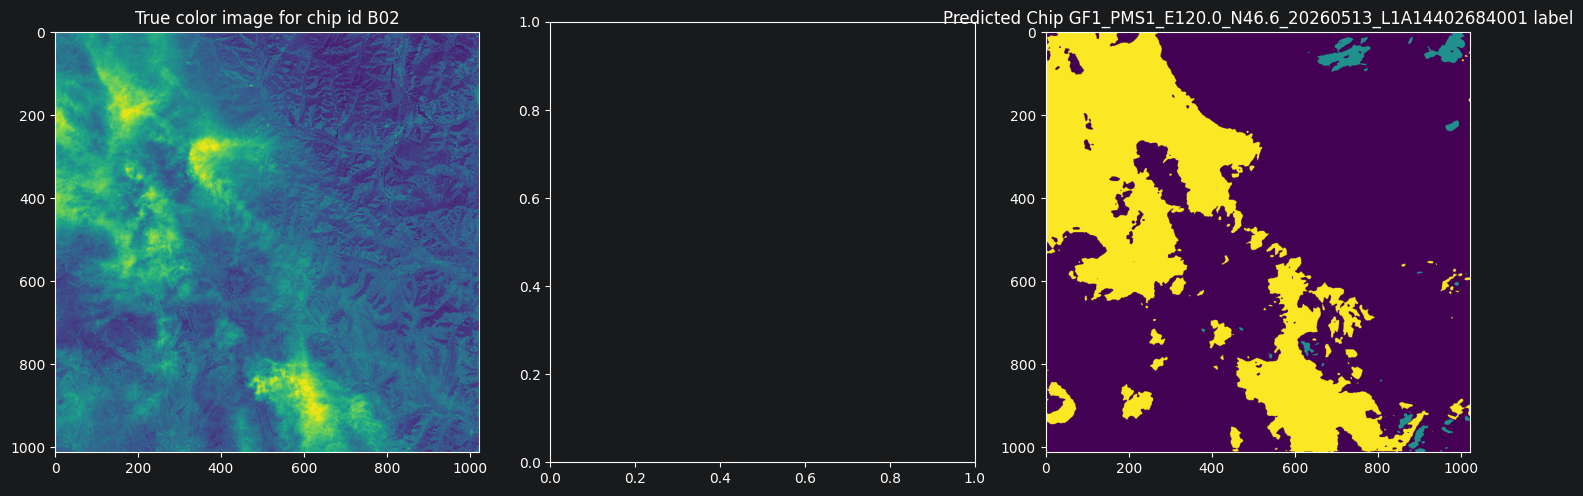

In [10]:
file = list(pred_out_dir.glob("*.tif"))

pred_files = random.sample(file, 12)
for pred_file in pred_files:
    img_file = img_in_dir / pred_file.stem / "B02.tif"
    label_file = label_out_dir / pred_file.name
    print(img_file, label_file)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    if img_file.exists():
        img = Image.open(img_file)
        ax[0].imshow(img)
        ax[0].set_title(f"True color image for chip id {img_file.stem}")
    if label_file.exists():
        label = Image.open(label_file)
        ax[1].imshow(label)
        ax[1].set_title(f"Chip {label_file.stem} label")
    if pred_file.exists():
        pred = Image.open(pred_file)
        ax[2].imshow(pred)
        ax[2].set_title(f"Predicted Chip {label_file.stem} label")
    plt.tight_layout()
    plt.show()